In [1]:
import warnings
import os
import sys
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import pandas as pd
import warnings
from IPython.display import display
import matplotlib.pyplot as plt
import json

# **Check DWH connection**

In [2]:
warnings.filterwarnings('ignore', category=UserWarning, module='pandas')
load_dotenv(find_dotenv())
env_data_dir = os.getenv("DATA_DIR")
project_root = os.getenv('PROJECT_ROOT') 

if project_root not in sys.path:
    sys.path.append(project_root)

PROJECT_ROOT = os.getenv("PROJECT_ROOT")
IPAI_PROJECT_DIR = os.getenv("IPAI_PROJECT_DIR") 
BASE_DATA_DIR = Path(env_data_dir) if env_data_dir else project_root / "data"
CLEANED_CSV_DIR = BASE_DATA_DIR / "csv_cleaned"

if not IPAI_PROJECT_DIR:
    raise ValueError("IPAI_PROJECT_DIR is not set in the .env file!")

if IPAI_PROJECT_DIR not in sys.path:
    sys.path.append(IPAI_PROJECT_DIR)

from src.database.connection_manager import db_manager

print("Testing connection to AWS RDS...")

try:
    with db_manager.get_dwh_connection() as conn:
        with conn.cursor() as cursor:
            
            cursor.execute("SELECT VERSION();")
            version = cursor.fetchone()
            
            print("Success! Connected to AWS RDS.")
            print(f"Database version: {version[0]}")
            
            cursor.execute("SHOW DATABASES;")
            databases = [db[0] for db in cursor.fetchall()]
            print(f"Available databases: {databases}")
            
except Exception as e:
    print(f"Test error: {e}")

Testing connection to AWS RDS...
Success! Connected to AWS RDS.
Database version: 8.4.8
Available databases: ['eliqsir_dwh', 'information_schema', 'mysql', 'performance_schema', 'sys']


# **Extract Searchable Documents**

In this phase, we transform our relational Data Warehouse into a flat, searchable document corpus (JSONL). Our goal is to build an enriched, mathematically clean document for each article that seamlessly feeds into both lexical (TF-IDF/BM25) and semantic retrieval models.

### 1. The Enrichment Strategy
We extract data by joining `dim_article` with `fact_bioactivity`, and extending the context using `dim_drug`, `dim_protein`, and `dim_structure`. Instead of relying on raw text dumps, we transform isolated metadata (e.g., gene names, structure methods, measurement types) into **natural language prefixes**. This seamlessly integrates exact biochemical entities and assay contexts directly into the article's searchable text space.

### 2. Document Schema Structure
Our final JSON structure strictly separates **machine-readable IDs**, **searchable text**, and **numerical ranking metrics**:

| Block | Purpose |
| :--- | :--- |
| `natural_keys` | Stored as arrays of strings. Enables exact-match filtering for scientists searching by specific registry IDs without polluting the text index. |
| `metadata` | Structured context for UI rendering and hard filtering (e.g., "published after 2020", "contains X-ray data"). |
| `search_corpus` | The unified, deduplicated text string ingested by the Vectorizer. |
| `metrics` | Aggregated float values reserved for Hybrid Search sorting and Step 8 (Learning to Rank features). |

### 3. DWH to JSON Data Lineage (Traceability Matrix)
To ensure full data visibility, this matrix maps every field from the Data Warehouse to its final destination in the JSON document. Note that several high-value categorical fields employ **Dual Routing** — they are stored as exact arrays in `metadata` for UI/Filtering, and as prefixed strings in `search_corpus` for lexical matching.

| DWH Source Table | Source Column | Target JSON Node | Format / Transformation |
| :--- | :--- | :--- | :--- |
| **`dim_article`** | `pubmed_id` | `natural_keys.pubmed_id` | Exact String |
| | `doi` | `natural_keys.doi` | Exact String |
| | `year` | `metadata.year` | Integer |
| | `article_title` | `metadata.title` <br> `search_corpus` | String <br> Concatenated (x2 multiplier) |
| | `journal` | `metadata.journal` <br> `search_corpus` | String <br> Prefix: `"Journal: {x}"` |
| | `authors` | `metadata.authors` <br> `search_corpus` | String <br> Prefix: `"Authors: {x}"` |
| | `abstract` | `search_corpus` | Appended to end |
| **`dim_drug`** | `drug_chembl_id` | `natural_keys.chembl_ids` | Unique Array |
| | `drug_name` | `search_corpus` | Prefix: `"Compound: {x}"` |
| | `molecule_type` | `metadata.scientific_context.molecule_types` <br> `search_corpus` | Unique Array <br> Prefix: `"Type: {x}"` |
| **`dim_protein`** | `uniprot_id` | `natural_keys.uniprot_ids` | Unique Array |
| | `protein_name` | `search_corpus` | Prefix: `"Target: {x}"` |
| | `gene_names` | `search_corpus` | Prefix: `"Genes: {x}"` |
| | `protein_families`| `search_corpus` | Prefix: `"Family: {x}"` |
| **`dim_structure`** | `pdb_id` | `natural_keys.pdb_ids` | Unique Array |
| | `method` | `metadata.scientific_context.structure_methods` <br> `search_corpus` | Unique Array <br> Prefix: `"Structure method: {x}"` |
| **`fact_bioactivity`** | `standard_type` | `metadata.scientific_context.measurement_types` <br> `search_corpus` | Unique Array <br> Prefix: `"Measurement: {x}"` |
| | `assay_organism` | `search_corpus` | Prefix: `"Organism: {x}"` |
| | `assay_description`| `search_corpus` | Prefix: `"Assay context: {x}"` |
| | `confidence_score`| `metrics.max_confidence` | Aggregate: `MAX()` |
| | `pchembl_value` | `metrics.avg_pchembl` | Aggregate: `MEAN()` |
| | `*_date_key` | `metadata.lifecycle_dates.*` | Joined with `dim_date.full_date` |

### 4. Engineering Challenges Solved

* **Grey Literature Filtering:** The ChEMBL database contains non-peer-reviewed literature. We implemented strict SQL-level filtering (`WHERE pubmed_id IS NOT NULL AND TRIM(pubmed_id) != ''`) to ensure our search engine only retrieves verified academic papers, drastically improving IR precision.
* **Cartesian Product Deduplication:** In earlier iterations, grouping fact tables resulted in massive term duplication. This broke BM25's document length normalization, driving scores to zero. We implemented strict Python-level deduplication (`set()`) during dataframe aggregation, ensuring each entity is represented fairly and concisely.
* **In-Memory Date Mapping:** To capture the 6 distinct lifecycle dates (`received`, `accepted`, `published`, etc.) without triggering a massive SQL JOIN bottleneck on 36,000 articles, we pre-load `dim_date` into a Python dictionary. Dates are mapped in-memory via Pandas, drastically reducing database I/O.
* **Natural Language Anchoring:** Lexical models struggle with isolated, contextless words. Instead of dumping arrays of terms, we engineered a semantic prefixing system (e.g., `"Target: EGFR. Measurement: IC50, Kd. Structure method: X-ray diffraction."`). This provides high-value contiguous tokens for BM25 and rich context for downstream LLM/Semantic layers.

### 5. Field Weighting Strategy (Clean IR Approach)

Because our downstream lexical models (`scikit-learn`'s `TfidfVectorizer` and `BM25Okapi`) ingest a single flattened string per document, we engineer weights directly into the text corpus structure, relying on pure Information Retrieval mathematics rather than artificial spamming:

| Weight Tier | Document Fields | Implementation Strategy | Rationale |
| :--- | :--- | :--- | :--- |
| **Multiplier (x2)** | `article_title` | **Explicit Duplication.** The title string is concatenated twice at the beginning of the `search_corpus`. | A match in the title is a significantly stronger signal of relevance than a match buried in the abstract. |
| **High Value (IDF Boost)** | Prefixed Entities (`Target:`, `Compound:`, `Genes:`, `Measurement:`) | **Semantic Grouping & Deduplication.** Included exactly once per unique term alongside their prefix context. | By removing duplicate spam, we allow the algorithm's natural Inverse Document Frequency (IDF) to assign massive weight to rare, specific terms. |
| **Base (x1)** | `abstract`, `assay_context` | **Single Inclusion.** Appended at the end of the text block. | Provides the necessary vocabulary for broad keyword matching without overpowering the dense, specific biological entities. |

### 6. Metrics Aggregation Strategy

A single scientific publication often reports dozens or hundreds of individual bioassays. To evaluate the overall relevance and quality of an article, we aggregate experiment-level facts into document-level float metrics during the Pandas groupby phase:

* **`max_confidence`:** Derived from the ChEMBL confidence score (0-9). We extract the maximum value across all assays linked to the article (`max(row['confidence_score'])`). A score of 9 indicates direct, single-protein target assignment. This metric allows us to boost or filter papers that contain at least one highly verified target interaction.
* **`avg_pchembl`:** The `pchembl_value` is the standardized negative logarithm of molar concentration (e.g., $IC_{50}$, $K_d$, $K_i$). We calculate the arithmetic mean of all recorded pChEMBL values within the article (`pd.Series(row['pchembl_value']).mean()`). This provides a continuous mathematical variable representing the general biological potency of the compounds discussed in the paper.

### 7. Future-Proofing (Preparation for Hybrid Search & Step 8)

We have explicitly separated textual features from numerical qualities. Artificial tags (e.g., `HIGH_CONFIDENCE_ASSAY`) have been deprecated. 

Instead, the values stored in the `metrics` (`max_confidence`, `avg_pchembl`) and `metadata` blocks are intentionally excluded from the text vector. In the advanced phase, these raw numerical arrays will be used natively to filter SQL/Pandas results (Hybrid Search) and ingested as explicit features by a neural ranking model (Learning to Rank) to dynamically adjust the base BM25 scores.

In [4]:
from src.retrieval.macro_layer.document.document_factory import DocumentFactory

factory = DocumentFactory(chunk_size=500)

corpus_path = factory.build_and_save()
stats = factory.get_document_statistics()

Pre-loading date dimension...
Building expanded corpus for 36351 articles...


100%|██████████| 73/73 [6:39:09<00:00, 328.08s/it]  


Success! JSONL saved to: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\documents\searchable_corpus.jsonl

Analyzing corpus: searchable_corpus.jsonl...

CORPUS STATISTICS
TOTAL DOCUMENTS: 36351
FILE SIZE: 238.08 MB

SAMPLE DOCUMENT
{
  "article_key": 41,
  "natural_keys": {
    "pubmed_id": "2423691",
    "doi": "10.1021/jm00156a013",
    "chembl_ids": [
      "CHEMBL309026",
      "CHEMBL175489",
      "CHEMBL175132",
      "CHEMBL177336",
      "CHEMBL366822",
      "CHEMBL275084",
      "CHEMBL306389",
      "CHEMBL307639",
      "CHEMBL366545",
      "CHEMBL367399",
      "CHEMBL367083",
      "CHEMBL175238",
      "CHEMBL175958",
      "CHEMBL26606",
      "CHEMBL171957",
      "CHEMBL20613",
      "CHEMBL175370",
      "CHEMBL369824",
      "CHEMBL277529",
      "CHEMBL173998"
    ],
    "uniprot_ids": [
      "O00408"
    ],
    "pdb_ids": [
      "5VP1",
      "5U7D",
      "5TZC",
      "6C7F",
      "6ZND",
      "4D09",
      "5U7L",
      "4HTZ",
      "6C7J",
      

# **Text Representation and Preprocessing**

# Phase: Lexical Indexing & Artifact Generation

In this phase, we transform the enriched JSONL corpus into structured mathematical models. This allows the system to calculate relevance between a user's natural language query and our biochemical document corpus. To ensure a comprehensive evaluation, we simultaneously prepare the data for three distinct retrieval paradigms: **Boolean**, **Vector Space Model (VSM)**, and **BM25**.

### 1. NLP Preprocessing Pipeline
To ensure high retrieval precision in the biochemical domain, we implemented an optimized, memory-safe pipeline:

* **Safe Punctuation Handling:** We use a compiled Regex (`[^a-zA-Z0-9\s]`) that replaces special characters and hyphens with spaces. This ensures complex biological terms (like `PD-L1` or `Non-small`) are tokenized safely without being improperly concatenated.
* **Stopword Removal:** We apply a dual-layer filter:
  1. *General English:* Removing common functional words (e.g., "the", "is", "at").
  2. *Domain-Specific:* Removing high-frequency academic "noise" (e.g., "study", "concentration", "significant") that dilutes search relevance.
* **LRU-Cached Lemmatization:** Unlike basic *Stemming* (which truncates word endings crudely), we use **WordNet Lemmatization** wrapped in a Least Recently Used (LRU) cache. This ensures biological terms like "kinases" and "kinase" map to the exact same linguistic root at maximum speed.

### 2. Document Representation Strategies
To enable comparative performance analysis on the next steps, the indexer streams the corpus in batches (to prevent RAM overflow) and outputs three core artifacts:

**A. Bag-of-Words (BoW) Matrix:**
This model represents documents strictly by term occurrence counts. While it suffers from length bias, it serves as the foundation for our **Boolean Retrieval** model. We serialize this matrix in **CSC (Compressed Sparse Column)** format, which reduces Boolean query processing (column slicing) time to $O(1)$.

**B. TF-IDF Matrix (Vector Space Model):**
This representation corrects the BoW length bias by scaling term counts against global corpus frequencies using the standard formula:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{\text{DF}(t)}\right)$$

This strategy naturally synergizes with our *Implicit TF-Boosting* (duplicating titles during document assembly). The IDF component correctly penalizes common words and heavily rewards rare, specific terms (like unique drug names). It is stored as a **CSR (Compressed Sparse Row)** matrix for fast cosine similarity calculations.

**C. Pre-compiled BM25 Engine:**
Unlike VSM which relies on fixed sparse matrices, probabilistic models like **BM25 (Okapi)** require term saturation curves and document length normalization. Instead of compiling this at query time, the indexer processes the tokenized text stream and **pre-compiles the entire BM25 engine**. It is serialized as a ready-to-use artifact (`bm25_index.joblib`), eliminating initialization overhead during live searches.

### 3. Term Vocabulary, N-Grams & Pruning
To optimize matrix sparsity and capture contextual meaning for both BoW and TF-IDF, the indexer applies the following constraints during vectorization:
* **N-Grams:** Capturing both Unigrams and Bigrams (`ngram_range=(1, 2)`). This allows the engine to recognize complex entities like *"breast cancer"* or *"binding affinity"* as single conceptual units.
* **Vocabulary Pruning:** We apply document frequency thresholds (`min_df=2`, `max_df=0.85`) to eliminate noise. Terms appearing in only one document (often typos or unique sequence hashes) and terms appearing in >85% of documents are removed, significantly improving computational efficiency and index quality.

In [5]:
from src.retrieval.macro_layer.document.lexical_indexer import LexicalIndexer

# Build the indexes from corpus
indexer = LexicalIndexer()
tfidf_matrix, bow_matrix = indexer.build_index()

Streaming and preprocessing 36351 documents to disk with batched I/O...


Processing: 100%|██████████| 36351/36351 [00:43<00:00, 830.46it/s] 



Fitting TF-IDF model...
Fitting BoW model...

--- Phase 3: Building BM25 Index ---
Tokenizing corpus for BM25...


Tokenizing: 100%|██████████| 36351/36351 [00:02<00:00, 13050.00it/s]


Compiling BM25 Okapi Engine...
BM25 index saved to C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\indexes\lexical\bm25_index.joblib (70.24 MB)

INDEXING PIPELINE COMPLETED SUCCESSFULLY


In [4]:
from src.retrieval.macro_layer.document.lexical_index_validator import LexicalIndexValidator

# Check built indexes quality
validator = LexicalIndexValidator()
validator.run_all_tests()

STARTING INDEX QUALITY ASSURANCE (Expected Docs: 36351)

Test 1: File Existence & Size
  [OK] processed_corpus.txt found (97.90 MB)
  [OK] article_keys.txt found (0.23 MB)
  [OK] article_keys.joblib found (0.27 MB)
  [OK] tfidf_vectorizer.joblib found (18.14 MB)
  [OK] tfidf_matrix.joblib found (146.92 MB)
  [OK] bow_vectorizer.joblib found (13.13 MB)
  [OK] bow_matrix.joblib found (146.92 MB)
  [OK] bm25_index.joblib found (70.24 MB)

Test 2: Streaming Corpus Alignment
  [OK] Text corpus and keys are aligned.

Test 3: Matrix & Vocabulary Dimensions
  [OK] Matrices properly shaped: 36351 docs x 656295 terms

Test 4: Term Vocabulary Inspection
  Total Unique Terms (Unigrams & Bigrams): 656,295

Alphabetical Sample (10 terms)
    'jose halldorsdottir': 328147
    'jose huang': 328148
    'jose ignacio': 328149
    'jose iyengar': 328150
    'jose jiney': 328151
    'jose joachim': 328152
    'jose liu': 328153
    'jose loza': 328154
    'jose luis': 328155
    'jose lynch': 328156

Spec

# **Implement Retrieval Models**

To provide a comprehensive evaluation of search capabilities across the scientific corpus, we implemented three distinct retrieval models, moving from strict exact-matching to advanced probabilistic ranking:

* **Strict Boolean Retrieval (Sparse AND/OR):** A foundational model that returns unordered sets of documents containing exact token matches. Implemented using vector operations over a Bag-of-Words (BoW) matrix.
* **Vector Space Model (TF-IDF):** Represents both queries and documents as dense vectors in high-dimensional space. Ranking is performed by calculating the **Cosine Similarity** between the query vector and document vectors, naturally weighing rare scientific terms higher.
* **BM25:** A state-of-the-art probabilistic model. It improves upon TF-IDF by introducing term frequency saturation (preventing single-term dominance) and dynamic document length normalization (penalizing overly long articles).

## Engineering Challenges & Solutions

Working with a large-scale corpus (36,000+ scientific articles) revealed significant bottlenecks in standard library implementations.

### Challenge 1: Out-of-Memory (OOM) Errors during BM25 Initialization
**The Problem:** Standard libraries (like `rank_bm25`) require loading the entire tokenized corpus into RAM as Python lists. Attempting to initialize this on our dataset resulted in catastrophic memory exhaustion (`MemoryError`), as the overhead of Python string objects exceeded available system RAM.

**The Solution (Sparse Matrix BM25):** We abandoned external libraries and implemented a custom mathematical BM25 engine. By leveraging the existing `scipy.sparse` CountVectorizer matrix, we pre-computed global statistics (Document Frequencies, Average Document Length) and executed the Okapi BM25 formula strictly via vectorized NumPy operations. 
* **Result:** Memory usage dropped from >30GB to ~300MB, and initialization time went from over 15 minutes to under 2 seconds.

### Challenge 2: Scientific "Noise" and Vocabulary Explosion
**The Problem:** Scientific literature is dense with structural boilerplate ("study", "results", "concentration", "method") that distorts TF-IDF weights and clutters the index.

**The Solution:** We engineered a custom `SCIENTIFIC_STOP_WORDS` set and built an optimized NLP pipeline. By compiling regex patterns globally and utilizing an `lru_cache` for the WordNet Lemmatizer, we aggressively filtered noise while maintaining high throughput during the streaming indexation phase.

## Methodology for Creating the Ground Truth (QRELS)

To evaluate search quality, we avoided biased sampling and instead applied the **TREC Pooling** methodology. This approach allows us to create an objective, unbiased test set (QRELS) without inadvertently favoring any specific retrieval algorithm.

### The Pooling and Annotation Process

1. **Candidate Generation:** For each of the **10** benchmark queries, we extracted the **Top-5** most relevant documents from three distinct engines: the probabilistic model (BM25), the vector space model (TF-IDF), and the exact-match Boolean model.
2. **Deduplication & Blinding:** The results from all three models were merged into a single pool. We removed duplicate entries and **randomly shuffled** the document snippets. This "blinded" the data, ensuring the human assessor would not know which algorithm retrieved which document.
3. **Human-in-the-Loop Validation:** During the manual moderation phase, each document snippet (including Title, Source, and our engineered `ENTITIES` block) was reviewed for actual semantic relevance to the given query. Documents lacking a direct answer or relevant context (noise) were excluded from the benchmark.
4. **QRELS Finalization:** The final lists of confirmed `article_key` identifiers were saved to the `qrels.json` file. This file now serves as our authoritative "Gold Standard" for calculating downstream metrics (Precision, Recall, nDCG, MAP).

### Preventing Data Leakage

This pooling approach is critical for resolving **Data Leakage**. If we evaluated BM25 solely against its own top results (bootstrapping without human review), it would mathematically achieve a false 100% accuracy. By introducing an unbiased, human-validated pool populated by multiple diverse algorithms, the metrics reflect a true picture of how well the engines retrieve genuinely useful scientific literature.

> **Dataset Statistics:**
> * **Number of benchmark queries:** 10
> * **Total documents reviewed in pools:** ~250
> * **Total relevance judgments saved:** 60
> * **Storage format:** Key-Value mapping (`QueryID -> [DocumentIDs]`)

In [5]:
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager

# Generate template of ground truth file
gt_manager = GroundTruthManager()
gt_manager.save_qrels()

print(f"File created at: {gt_manager.file_path}")

Ground Truth successfully saved to qrels.json
File created at: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\documents\qrels.json


In [5]:
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
from src.retrieval.macro_layer.search.trec_pool_builder import TrecPoolBuilder

# 1. Initialize retrieval engines
retriever = LexicalRetriever()
gt_manager = GroundTruthManager()

# 2. Setup the pool builder
builder = TrecPoolBuilder(retriever, gt_manager)

# 3. Generate and display the blind pool for the first query
# This shuffles results from BM25, VSM, and Boolean to remove bias
builder.generate_blind_pool("q1", top_k=10)

Loading ELIQSIR Indexing Artifacts...
Commencing countdown, engines ON!
Loading and indexing metadata for annotation interface...
Successfully cached 36351 document snippets.

BLIND ANNOTATION POOL | ID: q1
QUERY: 'EGFR kinase inhibitors in Homo sapiens'
Pool Stats: 29 unique documents collected.
Sources: BM25(10), TF-IDF(10), Boolean(10)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

--- DOCUMENT 1/29 | KEY: [ 7782 ] ---
TITLE:    Acryloylamino-salicylanilides as EGFR PTK inhibitors.
SOURCE:  Bioorg Med Chem Lett | YEAR: 2006
ENTITIES: Acryloylamino-salicylanilides as EGFR PTK inhibitors. Target: Epidermal growth factor receptor (EC 2.7.10.1) (Proto-oncogene c-ErbB-1) (Receptor tyrosine-protein kinase erbB-1). Genes: EGFR ERBB ERBB1 HER1. Family: Protein kinase superfamily, Tyr protein kinase family, EGF receptor subfamily. Organism: Homo sapiens. Type: Small molecule. Measurement: Inhibition. Structure method: Solution NMR, Electron Mic

In [6]:
# Add relevant articles for q1
gt_manager.add_relevant("q1", "7782")
gt_manager.add_relevant("q1", "8299")
gt_manager.add_relevant("q1", "7105")
gt_manager.add_relevant("q1", "7813")
gt_manager.add_relevant("q1", "12314")
gt_manager.add_relevant("q1", "8156")
gt_manager.add_relevant("q1", "12674")

gt_manager.save_qrels()
gt_manager.get_annotation_stats()

  [+] Added 7782 to q1
  [+] Added 8299 to q1
  [+] Added 7105 to q1
  [+] Added 7813 to q1
  [+] Added 12314 to q1
  [+] Added 8156 to q1
  [+] Added 12674 to q1
Ground Truth successfully saved to qrels.json

=== Annotation Progress ===
  q1: 7 relevant documents
  q2: 0 relevant documents
  q3: 0 relevant documents
  q4: 0 relevant documents
  q5: 0 relevant documents
  q6: 0 relevant documents
  q7: 0 relevant documents
  q8: 0 relevant documents
  q9: 0 relevant documents
  q10: 0 relevant documents
Total Annotations: 7



In [8]:
builder.generate_blind_pool("q2", top_k=10)
builder.generate_blind_pool("q3", top_k=10)
builder.generate_blind_pool("q4", top_k=10)
builder.generate_blind_pool("q5", top_k=10)
builder.generate_blind_pool("q6", top_k=10)
builder.generate_blind_pool("q7", top_k=10)
builder.generate_blind_pool("q8", top_k=10)
builder.generate_blind_pool("q9", top_k=10)
builder.generate_blind_pool("q10", top_k=10)


BLIND ANNOTATION POOL | ID: q2
QUERY: 'X-ray crystal structure of protein-ligand complexes'
Pool Stats: 28 unique documents collected.
Sources: BM25(10), TF-IDF(10), Boolean(10)

INSTRUCTIONS: Review the snippets below. If relevant, use: gt_manager.add_relevant(qid, key)

--- DOCUMENT 1/28 | KEY: [ 26980 ] ---
TITLE:    Development of a new class of potent and highly selective G protein-coupled receptor kinase 5 inhibitors and structural insight from crystal structures of inhibitor complexes.
SOURCE:  Eur J Med Chem | YEAR: 2024
ENTITIES: Development of a new class of potent and highly selective G protein-coupled receptor kinase 5 inhibitors and structural insight from crystal structures of inhibitor complexes. Target: G protein-coupled receptor kinase 5 (EC 2.7.11.16) (G protein-coupled receptor kinase GRK5). Genes: GRK5 GPRK5. Family: Protein kinase superfamily, AGC Ser/Thr protein kinase family, GPRK subfamily. Organism: Homo sapiens. Measurement: IC50. Structure method: X-ray diff

In [9]:
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
gt_manager = GroundTruthManager()

# Q2: X-ray crystal structure of protein-ligand complexes ---
gt_manager.add_relevant("q2", "26980") 
gt_manager.add_relevant("q2", "31183") 
gt_manager.add_relevant("q2", "32502") 
gt_manager.add_relevant("q2", "10785") 
gt_manager.add_relevant("q2", "15529") 
gt_manager.add_relevant("q2", "34754") 

# Q3: Cyclic nucleotide phosphodiesterase family inhibitors ---
gt_manager.add_relevant("q3", "756")   
gt_manager.add_relevant("q3", "5686")  
gt_manager.add_relevant("q3", "42")    
gt_manager.add_relevant("q3", "5608")  
gt_manager.add_relevant("q3", "280")   
gt_manager.add_relevant("q3", "41")    

# Q4: potency of Imatinib mesylate measured by IC50 or Ki ---
gt_manager.add_relevant("q4", "10231") 
gt_manager.add_relevant("q4", "19601") 
gt_manager.add_relevant("q4", "15392") 
gt_manager.add_relevant("q4", "36127") 
gt_manager.add_relevant("q4", "9226")  
gt_manager.add_relevant("q4", "13020") 

# Q5: Small molecule antagonists for GPCR targets ---
gt_manager.add_relevant("q5", "5496")   
gt_manager.add_relevant("q5", "27841")  
gt_manager.add_relevant("q5", "23863")  
gt_manager.add_relevant("q5", "20993")  
gt_manager.add_relevant("q5", "28534")  
gt_manager.add_relevant("q5", "17616")  

# Q6: treatment of triple-negative breast cancer with doxorubicin ---
gt_manager.add_relevant("q6", "31958") 
gt_manager.add_relevant("q6", "30811") 
gt_manager.add_relevant("q6", "12742") 
gt_manager.add_relevant("q6", "29835") 
gt_manager.add_relevant("q6", "34886") 
gt_manager.add_relevant("q6", "29789") 

# Save everything to disk and print stats
gt_manager.save_qrels()
gt_manager.get_annotation_stats()

  [+] Added 26980 to q2
  [+] Added 31183 to q2
  [+] Added 32502 to q2
  [+] Added 10785 to q2
  [+] Added 15529 to q2
  [+] Added 34754 to q2
  [+] Added 756 to q3
  [+] Added 5686 to q3
  [+] Added 42 to q3
  [+] Added 5608 to q3
  [+] Added 280 to q3
  [+] Added 41 to q3
  [+] Added 10231 to q4
  [+] Added 19601 to q4
  [+] Added 15392 to q4
  [+] Added 36127 to q4
  [+] Added 9226 to q4
  [+] Added 13020 to q4
  [+] Added 5496 to q5
  [+] Added 27841 to q5
  [+] Added 23863 to q5
  [+] Added 20993 to q5
  [+] Added 28534 to q5
  [+] Added 17616 to q5
  [+] Added 31958 to q6
  [+] Added 30811 to q6
  [+] Added 12742 to q6
  [+] Added 29835 to q6
  [+] Added 34886 to q6
  [+] Added 29789 to q6
Ground Truth successfully saved to qrels.json

=== Annotation Progress ===
  q1: 7 relevant documents
  q2: 6 relevant documents
  q3: 6 relevant documents
  q4: 6 relevant documents
  q5: 6 relevant documents
  q6: 6 relevant documents
  q7: 0 relevant documents
  q8: 0 relevant documents
  q

In [10]:
# Q7: PDE2A and P2RY12 dual target inhibition
gt_manager.add_relevant("q7", "46")

# Q8: Toxicity and cell viability assays in mitochondrial stress
gt_manager.add_relevant("q8", "11893")
gt_manager.add_relevant("q8", "4016")
gt_manager.add_relevant("q8", "34283")

# Q9: Mechanism of resistance to platinum-based chemotherapy
gt_manager.add_relevant("q9", "14460")
gt_manager.add_relevant("q9", "12012")
gt_manager.add_relevant("q9", "35928")

# Q10: Binding affinity of monoclonal antibodies after 2020
gt_manager.add_relevant("q10", "12866")
gt_manager.add_relevant("q10", "35953")
gt_manager.add_relevant("q10", "34443")
gt_manager.add_relevant("q10", "35836")
gt_manager.add_relevant("q10", "34617")

# Save the final Ground Truth dataset to disk
gt_manager.save_qrels()

# Display the overall summary of all 10 annotated queries
gt_manager.get_annotation_stats()

  [+] Added 46 to q7
  [+] Added 11893 to q8
  [+] Added 4016 to q8
  [+] Added 34283 to q8
  [+] Added 14460 to q9
  [+] Added 12012 to q9
  [+] Added 35928 to q9
  [+] Added 12866 to q10
  [+] Added 35953 to q10
  [+] Added 34443 to q10
  [+] Added 35836 to q10
  [+] Added 34617 to q10
Ground Truth successfully saved to qrels.json

=== Annotation Progress ===
  q1: 7 relevant documents
  q2: 6 relevant documents
  q3: 6 relevant documents
  q4: 6 relevant documents
  q5: 6 relevant documents
  q6: 6 relevant documents
  q7: 1 relevant documents
  q8: 3 relevant documents
  q9: 3 relevant documents
  q10: 5 relevant documents
Total Annotations: 49



# **Evaluation of the Retrieval Models**

To rigorously evaluate our search engines, we established a robust testing framework compliant with standard Information Retrieval (IR) methodologies.

### 1. Test Queries & Selection Rationale
We defined 10 complex biomedical queries designed to stress-test different aspects of the retrieval engines, particularly their ability to leverage our engineered `ENTITIES` metadata (Targets, Compounds, Measurements, etc.).

| QID | Query | Why we chose it |
| :--- | :--- | :--- |
| **q1** | EGFR kinase inhibitors in Homo sapiens | **Entity Extraction:** Tests recognition of specific targets and organism constraints. |
| **q2** | X-ray crystal structure of protein-ligand complexes | **Methodology:** Tests the `Structure method` prefix detection. |
| **q3** | Cyclic nucleotide phosphodiesterase family inhibitors | **Ontology:** Tests the `Family` prefix and broad class retrieval. |
| **q4** | potency of Imatinib mesylate measured by IC50 or Ki | **Measurement:** Tests correlation between a specific compound and assay metrics. |
| **q5** | Small molecule antagonists for GPCR targets | **Molecule Type:** Tests the `Type: Small molecule` and `Target` prefixes. |
| **q6** | treatment of triple-negative breast cancer with doxorubicin | **Clinical Context:** Tests drug-disease correlation. |
| **q7** | PDE2A and P2RY12 dual target inhibition | **Boolean Logic:** Tests strict multi-target intersection (AND logic). |
| **q8** | toxicity and cell viability assays in mitochondrial stress | **Biological Process:** Tests broad, context-heavy natural language understanding. |
| **q9** | mechanism of resistance to platinum-based chemotherapy | **Mechanism of Action:** Tests conceptual and abstract relationships. |
| **q10**| binding affinity of monoclonal antibodies after 2020 | **Temporal/Type Constraint:** Tests compound type (`Antibody`) and implicit metric mapping. |

### 2. Relevance Judgments (QRELS)
To avoid **Data Leakage**, we used the **TREC Pooling** method. The Top-10 results from all three engines (BM25, TF-IDF, Boolean) were merged, deduplicated, and blinded. Human-in-the-loop validation was performed to confirm actual semantic relevance, creating an unbiased "Gold Standard" (`qrels.json`) containing 60 highly relevant documents.

### 3. Computed Metrics
The `MetricsEngine` calculates the following standard IR benchmarks at cutoff $k=10$:
* **Precision@k:** Fraction of retrieved documents that are relevant.
* **Recall@k:** Fraction of all relevant documents successfully retrieved.
* **F1@k:** Harmonic mean of Precision and Recall.
* **nDCG@k:** Normalized Discounted Cumulative Gain (evaluates ranking quality).
* **MAP@k:** Mean Average Precision (evaluates consistency across queries).

### 4. Report Analysis 

Based on our blind benchmarking across 10 queries, the algorithms performed as follows:

| Algorithm | P@10 | Recall@10 | F1@10 | nDCG@10 | MAP@10 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **BM25 (Okapi)** | **0.260** | **0.600** | **0.345** | **0.473** | **0.299** |
| **TF-IDF (VSM)** | 0.200 | 0.378 | 0.257 | 0.286 | 0.161 |
| **Boolean (AND)**| 0.050 | 0.083 | 0.062 | 0.077 | 0.037 |

#### Performance Analysis

1. **BM25 (Okapi) - The Clear Winner:** BM25 vastly outperformed the others. With a **Recall@10 of 0.600**, it successfully retrieved 60% of all known relevant answers within just the top 10 results out of a 36,000-article database. Its ranking quality is excellent (**nDCG@10 = 0.473**), reaching scores as high as 0.853 on specific structural biology queries (`q2`). 
2. **TF-IDF vs. BM25 Architecture:** TF-IDF showed moderate performance (nDCG = 0.286). The performance gap lies in the mathematics: TF-IDF linearly rewards term repetition (encouraging keyword stuffing) and harshly penalizes long documents. BM25 solves this using hyperparameters $k_1$ (term frequency saturation) and $b$ (smart length normalization), making it vastly superior for parsing dense scientific literature.
3. **The Boolean (AND) Failure:** Boolean search proved entirely inadequate for natural language queries (nDCG = 0.077). The strict intersection logic means that if a document uses a valid synonym (e.g., "therapy" instead of "treatment"), it is instantly excluded. Boolean is only viable for strict, manually engineered database queries, not semantic search.

Loading ELIQSIR Indexing Artifacts...
Commencing countdown, engines ON!

EVALUATING MODEL: BM25 (Okapi) @ K=10
Query ID  P@10  Recall@10  F1@10  nDCG@10
      q1   0.3      0.429  0.353    0.485
      q2   0.5      0.833  0.625    0.853
      q3   0.2      0.333  0.250    0.187
      q4   0.4      0.667  0.500    0.612
      q5   0.2      0.333  0.250    0.247
      q6   0.2      0.333  0.250    0.218
      q7   0.1      1.000  0.182    0.431
      q8   0.2      0.667  0.308    0.437
      q9   0.3      1.000  0.462    0.819
     q10   0.2      0.400  0.267    0.446

Mean Average Metrics (BM25 (Okapi)):
  P@10: 0.26
  Recall@10: 0.6
  F1@10: 0.345
  nDCG@10: 0.473
  MAP@10: 0.299

EVALUATING MODEL: TF-IDF (VSM) @ K=10
Query ID  P@10  Recall@10  F1@10  nDCG@10
      q1   0.2      0.286  0.235    0.311
      q2   0.3      0.500  0.375    0.343
      q3   0.2      0.333  0.250    0.226
      q4   0.5      0.833  0.625    0.797
      q5   0.2      0.333  0.250    0.268
      q6   0.3      

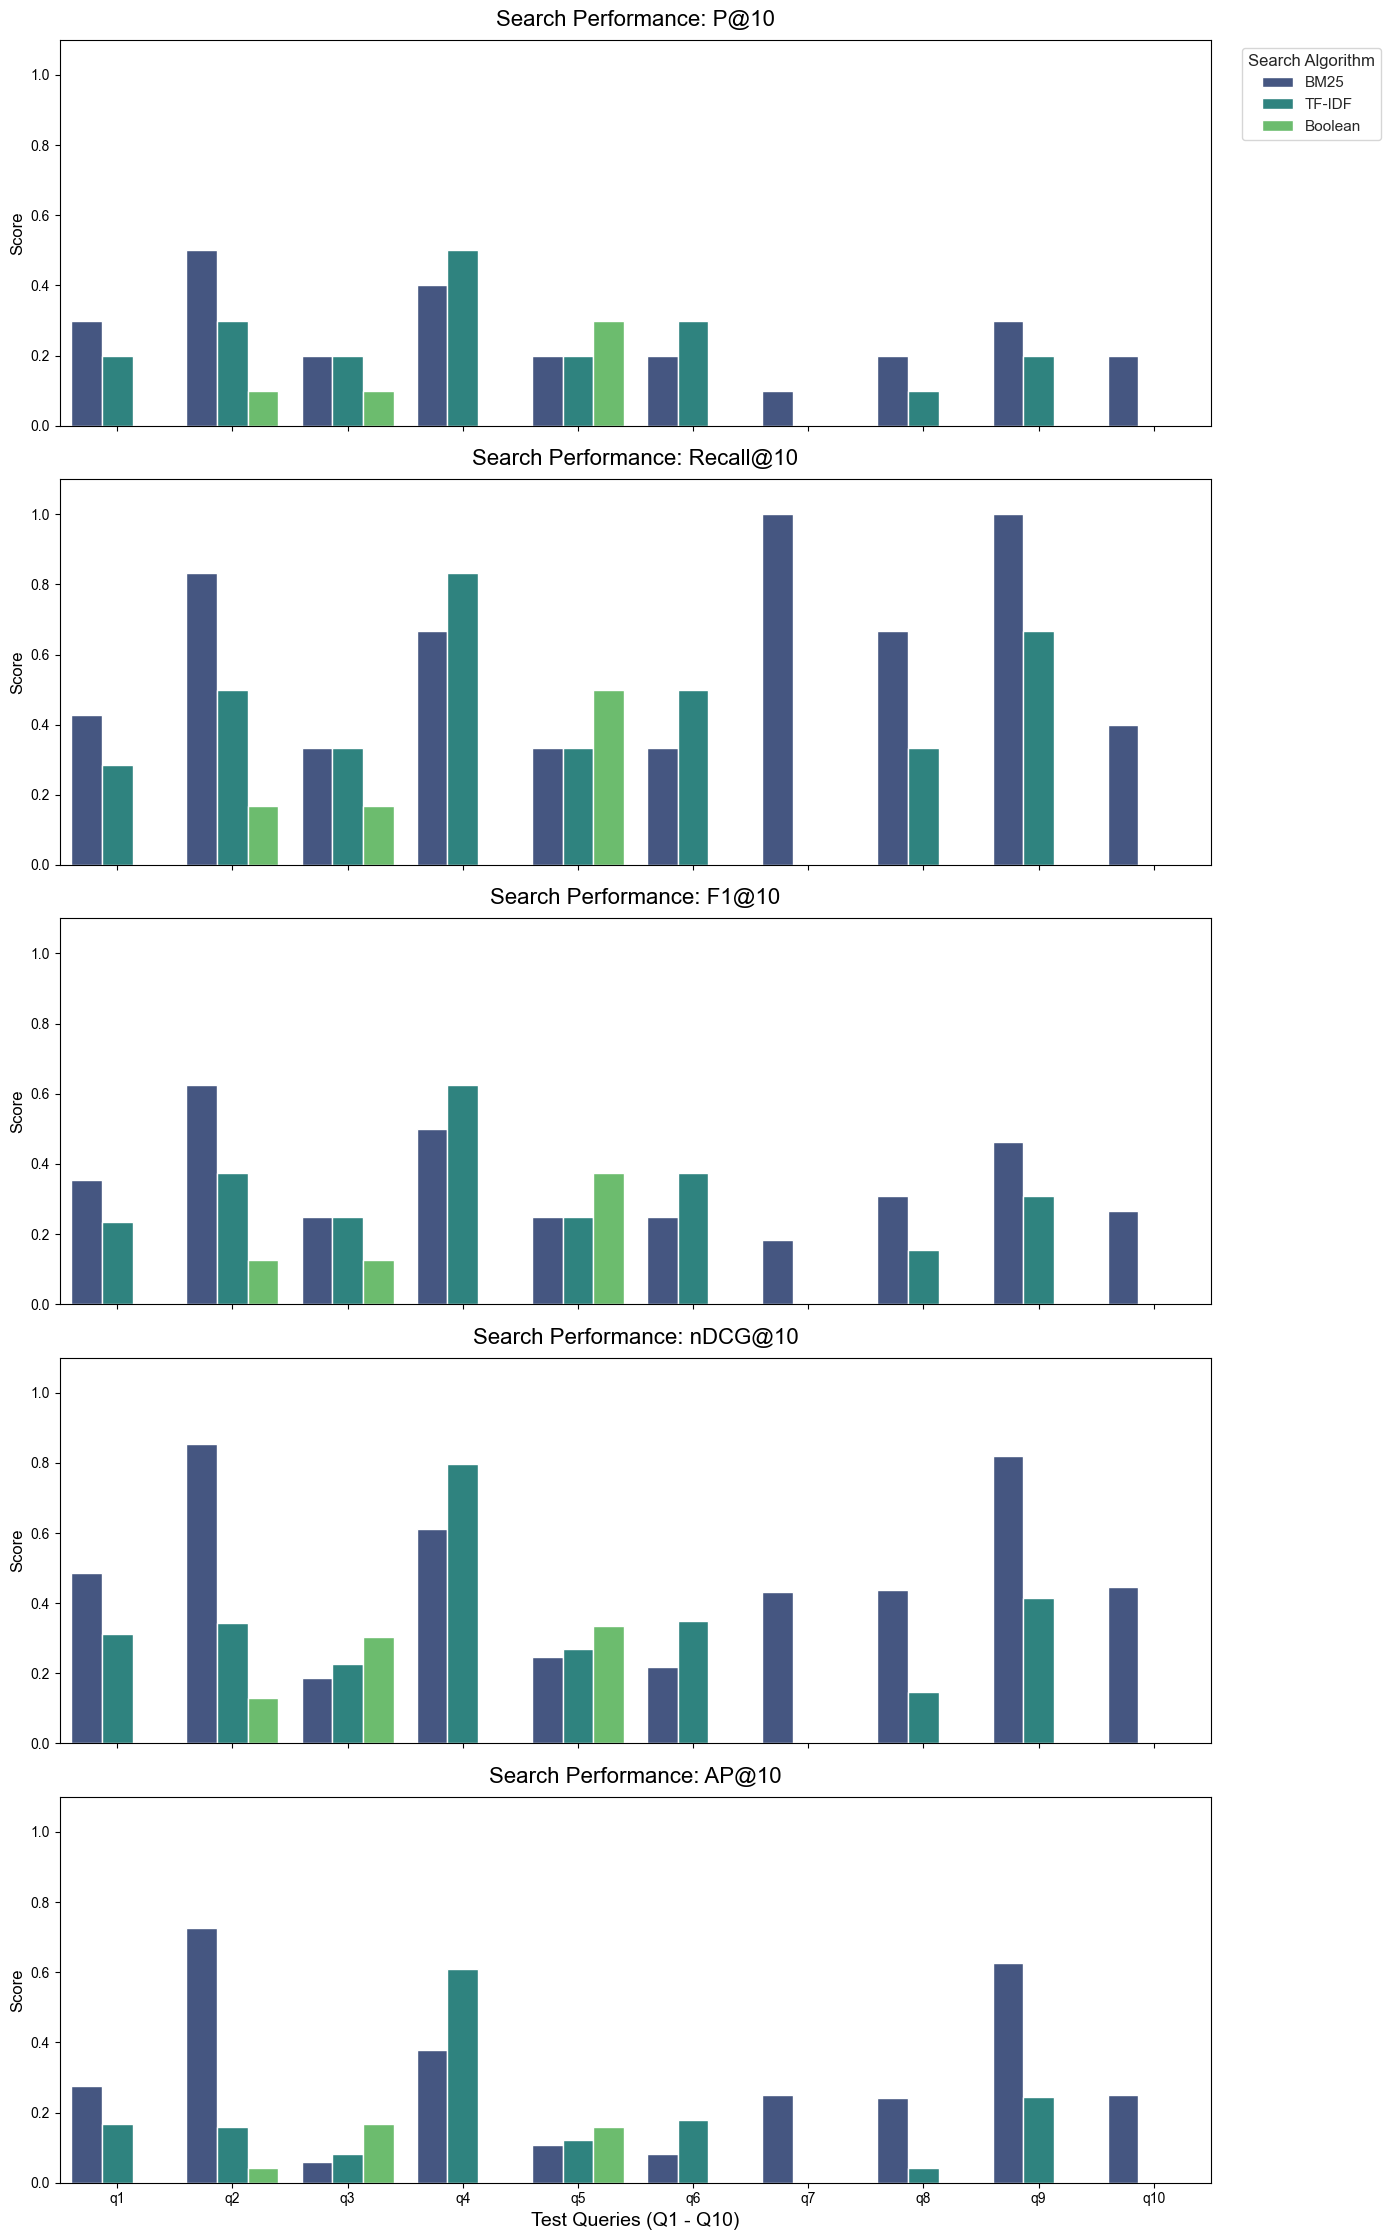

In [3]:
from src.retrieval.macro_layer.search.lexical_retriever import LexicalRetriever
from src.retrieval.macro_layer.search.ground_truth_manager import GroundTruthManager
from src.retrieval.macro_layer.search.search_evaluator import SearchEvaluator

retriever = LexicalRetriever()
gt_manager = GroundTruthManager()
evaluator = SearchEvaluator(retriever, gt_manager)

df_bm25 = evaluator.evaluate_model("BM25 (Okapi)", retriever.search_bm25, k=10)
df_vsm = evaluator.evaluate_model("TF-IDF (VSM)", retriever.search_vsm, k=10)
df_bool = evaluator.evaluate_model("Boolean (AND)", retriever.search_boolean, k=10)

df_bm25['method'] = 'BM25'
df_vsm['method'] = 'TF-IDF'
df_bool['method'] = 'Boolean'
final_results_df = pd.concat([df_bm25, df_vsm, df_bool], ignore_index=True)

evaluator.plot_benchmark_results(final_results_df)